### Récuit Simulé 
_______________________________________________________________________________________________________________
### Auteur : Luc Carlos Asso

### _______________________________________________________________________________________________________________

### Importation des Packages

### _______________________________________________________________________________________________________________

In [140]:
import re
import numpy as np
import random
import matplotlib.pyplot as plt
import time 

### _______________________________________________________________________________________________________________

### Recuit en mode classe

### """  Informations :
            ‣ T  read_instance(filename) : recupération des instances
            ‣ Fonction_objectif( x : np.ndarray , λ : np.ndarray) : Fonction Objectif
            ‣ Solution_Initiale() : Solution Intiale
            ‣ voisin_swp(x : np.ndarray): Voisin de x
            ‣ Voisinage() : Voisinage du dernier élément de l'historique des solutions réalisables
            ‣ Sauvegarder(solution : np.ndarray) : Sauvegarder les solutions
            ‣ Meilleurs_solutions() : les meilleurs solutions réalisables
     """

In [1138]:
class recuit_simule :
    
    @staticmethod
    def read_instance(filename):
        with open(filename, "r") as f:
            lines = [line.strip() for line in f if line.strip()]
        n = int(re.findall(r'\d+', lines[1])[0])                                      # -------- n --------------
        profits = [[0]*n for _ in range(n)]                                           # -------- profits --------
        idx = 3
        for i in range(n):
            nums = list(map(int, re.findall(r'-?\d+', lines[idx])))
            for j in range(i+1):
                profits[i][j] = nums[j]
                profits[j][i] = nums[j]
            idx += 1

        idx += 1  # saute "#Weights:"
        weights = list(map(int, re.findall(r'-?\d+', lines[idx])))                    # -------- poids -----------
        capacity = int(re.findall(r'\d+', lines[idx+1])[0])                           # -------- capacity --------
        k = int(re.findall(r'\d+', lines[idx+2])[0])                                  # -------- k ---cardinalité-
        return n, profits, weights, capacity, k


    n, P, W, C, k = recuit_simule.read_instance("Instance.txt")
    P = np.array(P)
    W = np.array(W)      

    @staticmethod
    def Fonction_objectif( x : np.ndarray , λ : np.ndarray) :
        Val1, Val2, Val3= 0,0,0
        for i in range(recuit_simule.n) :
            Val1+= recuit_simule.W[i]*x[i]
            Val2+=recuit_simule.P[i,i]*x[i]*x[i]
            for j in range(i+1,recuit_simule.n) : 
                    Val3+= recuit_simule.P[i,j]*x[i]*x[j]
        Val4= λ[0]*(recuit_simule.read_instance("Instance.txt")[3] - Val1) 
        Val5= λ[1]*( recuit_simule.read_instance("Instance.txt")[4] - int(sum(x)))
        return Val1 + Val2 + Val3 + Val4+ Val5

        
    """
    Variables :
    ‣   k : nombre de 1 dans la solution Initiale 
    ‣   n : la taille de l'instance
    """  
    """@staticmethod
    
    def Solution_Initiale() :    
            n=recuit_simule.read_instance("Instance.txt")[0] 
            k=recuit_simule.read_instance("Instance.txt")[4] # pour respecter la contrainte de cardinalité
            Sol_I=[0]*n
            indices = random.sample(range(n), k) # indices de valeur 1 de la solution Initiale
            for i in indices : 
                Sol_I[i]=1
            return np.array(Sol_I)

    """ 
    """
    @staticmethod
    def Solution_Initiale():
        n, P, W, C, k = recuit_simule.read_instance("Instance.txt")
        Sol_I = np.zeros(n, dtype=int)
        indices = list(range(n))
        random.shuffle(indices)
        Stock_poids=[]
        poids_total = 0
        nb_objets = 0
        while True :
            indice=0
            for i in indices:               # vérifier capacité
                W1=W[i]
                if poids_total + W1 <= C:
                    Sol_I[i] = 1
                    poids_total += W1
                    indice = i
                    nb_objets += 1
                    indices.remove(i)
                    Stock_poids.append(W1)
                if nb_objets == k:           # cardinalité atteinte
                    break
            if nb_objets < k:
                Sol_I[indice] =0 
                poids_total-= Stock_poids[-1]
                random.shuffle(indices)
        return Sol_I
        """
    @staticmethod
    def Solution_Initiale():
        Sol_I = np.zeros(recuit_simule.n, dtype=int)
        indices = np.argsort(recuit_simule.W)            # indices triés par poids croissant
        poids_total = 0 
        nb_objets = 0
        for i in indices:
            if poids_total + recuit_simule.W[i] <= recuit_simule.C:   # vérifier capacité
                Sol_I[i] = 1
                poids_total += recuit_simule.W[i]
                nb_objets += 1
            if nb_objets == recuit_simule.k:            # cardinalité atteinte
                  break
        if nb_objets < recuit_simule.k:                 # vérification finale
            raise ValueError(
                "Le Problème n'admet pas de solution"
            )
        return Sol_I
            
                
    @staticmethod
    def voisin_swp(x: np.ndarray):
        v = x.copy()
        indices_1 = [i for i in range(len(v)) if v[i] == 1]
        indices_0 = [i for i in range(len(v)) if v[i] == 0]
        i = random.choice(indices_1)
        j = random.choice(indices_0)
        v[i] = 0
        v[j] = 1
        return v

    """
    @staticmethod
    def Voisinage() : 
        Voisinage = []
        W= np.array(recuit_simule.read_instance("Instance.txt")[2])  # Poids des objets
        C=recuit_simule.read_instance("Instance.txt")[3] # Capacité
        x = recuit_simule.Historique_Sol[-1]
        for i in range(10) :
            v = recuit_simule.voisin_swp(x)
            if np.dot(v,W)<= C:
                Voisinage.append(v)
        if len(Voisinage) == 0:
            Voisinage.append(x.copy())
        return Voisinage
    """

    @staticmethod
    def Voisinage():
        voisins = []
        deja_vus = set()
        x = recuit_simule.Historique_Sol[-1]
        essais = 0
        while len(voisins) < 10 : # and essais < 1000:
            v = recuit_simule.voisin_swp(x)
            t = tuple(v)
            if t not in deja_vus : # and np.dot(v, recuit_simule.W) <= recuit_simule.C:
                voisins.append(v)
                deja_vus.add(t)
            essais += 1
        if len(voisins) == 0:
            voisins.append(x.copy())
        return voisins
        
    """
        Paramètres 
            ‣ T  Température
            ‣ taux_d  taux de décroissance
            ‣ ɛ : paramètre de condition 
            ‣ λ : paramètre de la fonction objectif
            ‣ k : nombre de 1 dans la solution Initiale 
     """
   
    Historique_Sol=[]  # Historique des solutions
    @staticmethod 
    def Recuit_simulé(T : float ,taux_d : float, ɛ : float, λ : np.ndarray):
        Sol_initiale = recuit_simule.Historique_Sol[-1]
        pas_pause=0
        const_cond_pause = int( (((T- ɛ)/taux_d) + 1)/2 )
        while T > ɛ :
            pas_pause = pas_pause + 1
            V_s = random.choice(recuit_simule.Voisinage())
            F_V_s = recuit_simule.Fonction_objectif(V_s, λ)         # image de  V_s par Fonction_objectif
            F_s = recuit_simule.Fonction_objectif(Sol_initiale, λ)  # image de la solution initiale par Fonction_objectif
            if F_V_s >  F_s : 
                Sol_initiale = V_s
            else:
                r = random.random()
                ΔF =  F_V_s -  F_s
                if r <= np.exp(ΔF/T) :
                    Sol_initiale = V_s
            recuit_simule.Sauvegarder(Sol_initiale)
            if pas_pause == const_cond_pause :                     # pause 
                time.sleep(180)                                
            T=T*taux_d 
        return Sol_initiale
        

    @staticmethod
    
    def Sauvegarder(solution : np.ndarray) :                       # Sauvegarder les solutions
        recuit_simule.Historique_Sol.append(solution.copy())

    @staticmethod
    def Meilleurs_solutions():
        Images_Sol = []
        for sol in recuit_simule.Historique_Sol:
            val = recuit_simule.Fonction_objectif(sol, λ)
            Images_Sol.append(val)
        Valeur_Max = max(Images_Sol)
        meilleurs_solutions = []
        for sol, val in zip(recuit_simule.Historique_Sol, Images_Sol):
            if val == Valeur_Max:
                meilleurs_solutions.append(sol)
        uniques = []
        for arr in meilleurs_solutions:
            deja_present = False
            for u in uniques:
                if np.array_equal(arr, u):
                    deja_present = True
                    break
            if not deja_present:
                uniques.append(arr.copy())
        return uniques

    estimation_lambda = []
    @staticmethod
    def Estimation_lambda(x : np.ndarray) :
        Val1, Val2, Val3= 0,0,0
        for i in range(recuit_simule.n) :
            Val1+= recuit_simule.W[i]*x[i]
            Val2+=recuit_simule.P[i,i]*x[i]*x[i]
            for j in range(i+1,recuit_simule.n) : 
                    Val3+= recuit_simule.P[i,j]*x[i]*x[j]
        lamb =((recuit_simule.Fonction_objectif( x ,λ ) - (Val2 + Val3) )/ (recuit_simule.C - Val1) )
        recuit_simule.estimation_lambda.append(lamb)
        return recuit_simule.estimation_lambda

    @staticmethod
    def est_ce_une_solution_realisable(x : np.ndarray) :
      if np.dot(x, recuit_simule.W) <= recuit_simule.C:
            return True
        
        

### Exécution 

In [1139]:
Solution_initiale = recuit_simule.Solution_Initiale()                         
recuit_simule.Sauvegarder(Solution_initiale)  # Initialiser le circuit avec une solution Initiale

In [1151]:
 λ=np.array([11.375,0])  # Valeur de lambda 

In [1141]:
debut= time.time()
recuit_simule.Recuit_simulé(110,0.99,0.1, λ)
fin= time.time()
temps= fin - debut

In [1142]:
heures = int(temps // 3600)
minutes = int ((temps % 3600) // 60)
secondes =  temps % 60
print(f"Temps d'exécution : {heures} h {minutes} min {secondes} s")

Temps d'exécution : 0 h 3 min 28.465514659881592 s


### Solutions réalisables

In [1143]:
recuit_simule.Historique_Sol

[array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
        0, 1]),
 array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
        0, 1]),
 array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
        0, 1]),
 array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,

### Meilleur(s) solution(s) réalisables

In [1144]:
x=recuit_simule.Meilleurs_solutions()

In [1145]:
x

[array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 1])]

### Est ce une solution réalisablr ?

In [1146]:
recuit_simule.est_ce_une_solution_realisable(x[0])

True

### Indices des 1 de la solutions

In [1147]:
sol = x[0]
indices = [i+1 for i,v in enumerate(sol) if v == 1]
print(indices)

[5, 9, 13, 25, 26, 31, 34, 44, 54, 64, 69, 70, 85, 89, 90]


In [1148]:
[5, 9, 11, 18, 29, 31, 34, 41, 44, 45, 54, 70, 73, 79, 82]

[5, 9, 11, 18, 29, 31, 34, 41, 44, 45, 54, 70, 73, 79, 82]

### Evolution du processus 

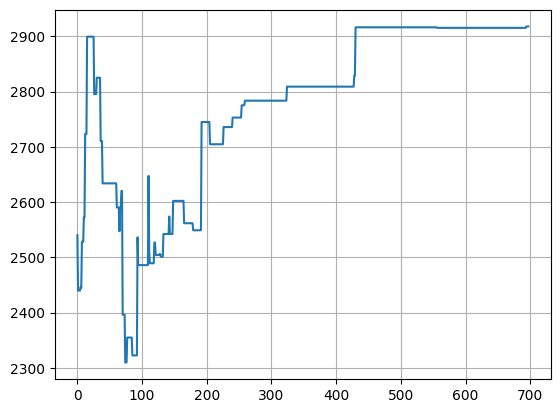

In [1149]:
Images_Sol= []
for i in recuit_simule.Historique_Sol :
    Images_Sol.append(recuit_simule.Fonction_objectif(i, λ))
plt.plot(Images_Sol) # Images des solutions par Fonction_objectif 
plt.grid()
plt.show()

### Valeur de la meilleure solution par Fonction_objectif 

In [1152]:
recuit_simule.Fonction_objectif( x[0],λ ) 

np.int64(2861)

### Vérifiez s'il y a plus meilleur que la solution trouvée précedement 

In [1097]:
"""La solution initiale est l'une des meilleurs solutions.
   recompiler à partir de la 3 ième cellule du champ Exécution.
"""
y =random.choice(x)
recuit_simule.Historique_Sol=[]
recuit_simule.Historique_Sol.append(y)

In [1098]:
recuit_simule.Historique_Sol

[array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 1])]

In [1122]:
recuit_simule.n=0
recuit_simule.C=0
recuit_simule.P=[]
recuit_simule.k=0
recuit_simule.W=[]

### Estimation de lambda 1 

In [1082]:
x=[0]*recuit_simule.n
for i in [6, 27, 35, 38, 45, 51, 52, 56, 81, 82, 97, 100, 106, 108, 137, 139, 154, 187] :
    x[i-1]=1
x = np.array(x)
recuit_simule.Estimation_lambda(x)

[np.float64(11.375)]

In [1049]:
recuit_simule.estimation_lambda

[np.float64(11.375)]

### Représentation de lambda 1 [ Estimation de son intervalle le plus restreint possible]

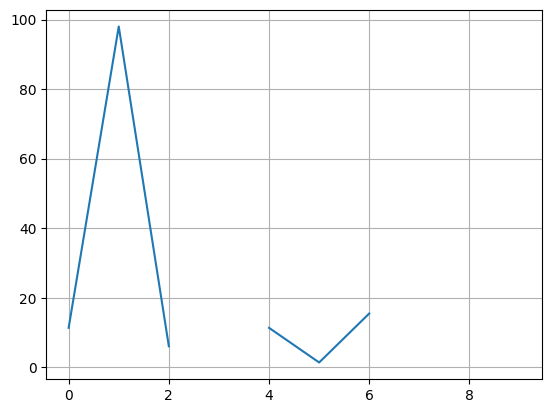

In [1084]:
lambda_itéré = [11.375,98.0,6.071428571428571,np.inf,11.375,1.4146341463414633,15.5,np.inf,np.inf,11.375]
plt.plot(lambda_itéré) 
plt.grid()
plt.show()

### _______________________________________________________________________________________________________________

### _______________________________________________________________________________________________________________

### _______________________________________________________________________________________________________________

### _______________________________________________________________________________________________________________

### _______________________________________________________________________________________________________________

In [ ]:
[5, 13, 19, 25, 26, 31, 32, 34, 37, 64, 69, 74, 83, 85, 90]

In [ ]:
[11.375,98.0,6.071428571428571,np.float64(inf),11.375,1.4146341463414633,15.5,np.float64(inf),np.float64(inf),11.375]

In [ ]:
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
[36, 40, 50, 68, 77]

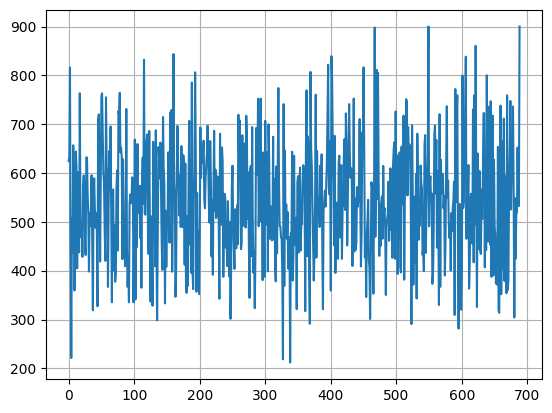

In [292]:
Images_Sol= []
for i in recuit_simule.Historique_Sol :
    Images_Sol.append(recuit_simule.Fonction_objectif(i, λ))
plt.plot(Images_Sol) # Images des solutions parFonction_objectif 
plt.grid()
plt.show()

In [78]:
meilleur = []
m = -float("inf")
for val in Images_Sol:
    m = max(m, val)
    meilleur.append(m)

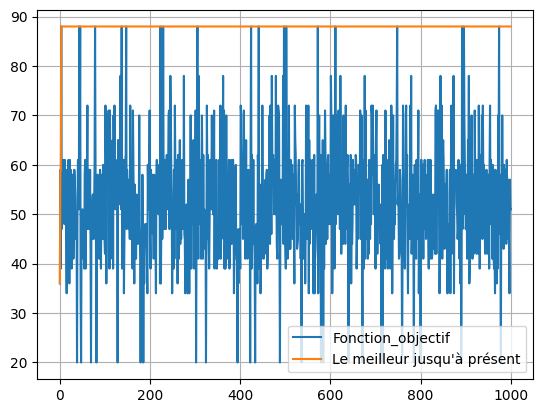

In [79]:
plt.plot(Images_Sol, label="Fonction_objectif")
plt.plot(meilleur, label="Le meilleur jusqu'à présent")
plt.legend()
plt.grid()
plt.show()

In [80]:
Valeur_Max= max(Images_Sol)
meilleurs_solutions = [sol for sol in recuit_simule.Historique_Sol if recuit_simule.Fonction_objectif(sol,λ)==Valeur_Max]
uniques = []
for arr in meilleurs_solutions:
    t = tuple(arr)
    if t not in uniques:
        uniques.append(t)
solutions=[tuple(int(x) for x in t) for t in uniques]      

### Solutions possibles

In [81]:
print(solutions)
print([8,6,10,6,6,11,10,3,2,8])

[(0, 1, 0, 0, 1, 0, 0, 0, 0, 0)]
[8, 6, 10, 6, 6, 11, 10, 3, 2, 8]


In [82]:
print([8,6,10,6,6,11,10,3,2,8])

[8, 6, 10, 6, 6, 11, 10, 3, 2, 8]


In [83]:
(0, 1, 0, 0, 1, 1, 0, 0, 0, 1), (1, 1, 0, 1, 0, 1, 0, 0, 0, 0)]
[array([0, 0, 0, 0, 1, 1, 0, 1, 0, 1])

SyntaxError: unmatched ']' (846398058.py, line 1)

In [ ]:
len(recuit_simule.Historique_Sol)

In [ ]:
"----------------------------------------------------------------------------------------------------------------------------"

In [2233]:
Valeur_Max 

np.float64(172.0)

In [ ]:
n, P, W, C, k= recuit_simule.read_instance("Instance.txt")

In [ ]:
recuit_simule.read_instance("Instance.txt")

In [ ]:
import random
n=10
k=4
indices = random.sample(range(n), k)

In [42]:
indices=[0,0,1,1,0]
indices.remove(1)
indices

[0, 0, 1, 0]

In [43]:
X= np.array(indices)
len(X)

4

In [2185]:
list(X)

[np.int64(3), np.int64(0), np.int64(1), np.int64(0)]

In [ ]:
X

In [ ]:
np.float64(0.0)== 0.0

In [ ]:
random.choice([0,1])

In [ ]:
ind_inv= random.randint(0,12)
ind_inv

In [ ]:
L=[2,8,8,6,2]
L.index(2)

In [2214]:
for i in range(2,4):
    print(i)

2
3


In [2]:
for i in range(5):
    print(i)
    if i == 2 : 
        break
    print(" je t'aime")
    

0
 je t'aime
1
 je t'aime
2


In [11]:
T=10
J=2
while T > 5 :
    print("Je t'aime mamana")
    if J== 0:
        break
    T-=1
    J-=1
    

Je t'aime mamana
Je t'aime mamana
Je t'aime mamana
